In [5]:
#Project 2: Car Price Prediction Dashboard
#Step 1: Install Libraries

!pip install pandas numpy scikit-learn matplotlib seaborn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 59.7 MB/s eta 0:00:00


In [7]:
#Step 2: Create Dataset (car_data.csv)
csv_content = """Year,Mileage,FuelType,Price
2018,30000,Petrol,600000
2017,40000,Diesel,550000
2020,15000,Petrol,850000
2019,25000,Diesel,700000
2016,50000,Petrol,450000
2021,10000,Diesel,950000
2015,60000,Petrol,400000
"""

with open("/content/Car Prdecit data .csv", "w") as file:
    file.write(csv_content)
print("Car dataset created successfully at /content/Car Prdecit data .csv")

Car dataset created successfully at /content/Car Prdecit data .csv


In [9]:
#Step 3: Load and Clean Dataset

import pandas as pd

data = pd.read_csv("/content/Car Prdecit data .csv")

print(data.head())
data.dropna(inplace=True)

   Year  Mileage FuelType   Price
0  2018    30000   Petrol  600000
1  2017    40000   Diesel  550000
2  2020    15000   Petrol  850000
3  2019    25000   Diesel  700000
4  2016    50000   Petrol  450000


In [10]:
#Step 4: Convert Fuel Type to Numeric
data = pd.get_dummies(data,
                      columns=['FuelType'],
                      drop_first=True)

print(data.head())

   Year  Mileage   Price  FuelType_Petrol
0  2018    30000  600000             True
1  2017    40000  550000            False
2  2020    15000  850000             True
3  2019    25000  700000            False
4  2016    50000  450000             True


In [11]:
#Step 5: Split Features and Target
X = data.drop("Price", axis=1)
y = data["Price"]

In [12]:
#Step 6: Train Regression Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

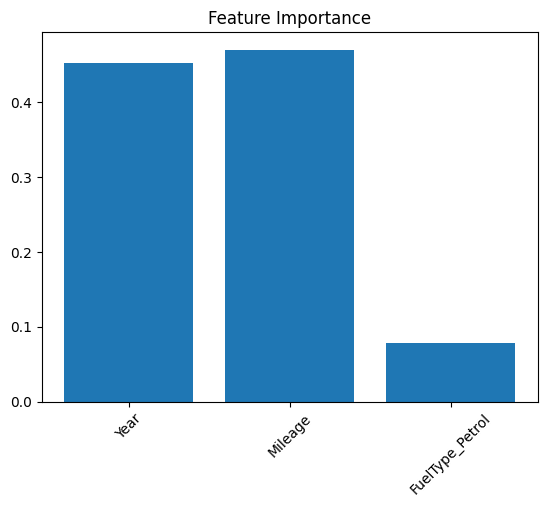

In [13]:
#Step 7: Feature Importance Visualization
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [14]:
#Step 8: Create Streamlit Dashboard
import streamlit as st
import pandas as pd

st.title("Car Price Prediction Dashboard")

year = st.number_input("Year", 2010, 2025, 2020)
mileage = st.number_input("Mileage", 0, 200000, 20000)

fuel = st.selectbox(
    "Fuel Type",
    ["Petrol", "Diesel"]
)

fuel_diesel = 1 if fuel == "Diesel" else 0

input_data = pd.DataFrame({
    "Year":[year],
    "Mileage":[mileage],
    "FuelType_Petrol":[0],
    "FuelType_Diesel":[fuel_diesel]
})

if st.button("Predict Price"):
    price = model.predict(input_data)
    st.success(f"Predicted Price: ₹ {price[0]:,.0f}")

2026-06-04 09:28:51.803 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:51.997 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-04 09:28:51.999 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:52.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:52.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:52.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:52.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:52.005 Thread 'MainThread': mi

In [15]:
#Step 9: Add Chart in Dashboard
st.subheader("Dataset Overview")
st.bar_chart(data["Price"])

2026-06-04 09:28:56.489 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:56.491 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:56.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:58.583 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:58.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 09:28:58.586 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [17]:
#Step 10: Run Dashboard
!streamlit run car_dashboard.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: car_dashboard.py
